<a href="https://colab.research.google.com/github/maggie20041027-svg/ECON3916-Statistical-Machine-Learning/blob/main/Assignment%204/Assignment_4_The_Predictive_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install category_encoders

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import missingno as msno
import category_encoders as ce
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import networkx as nx

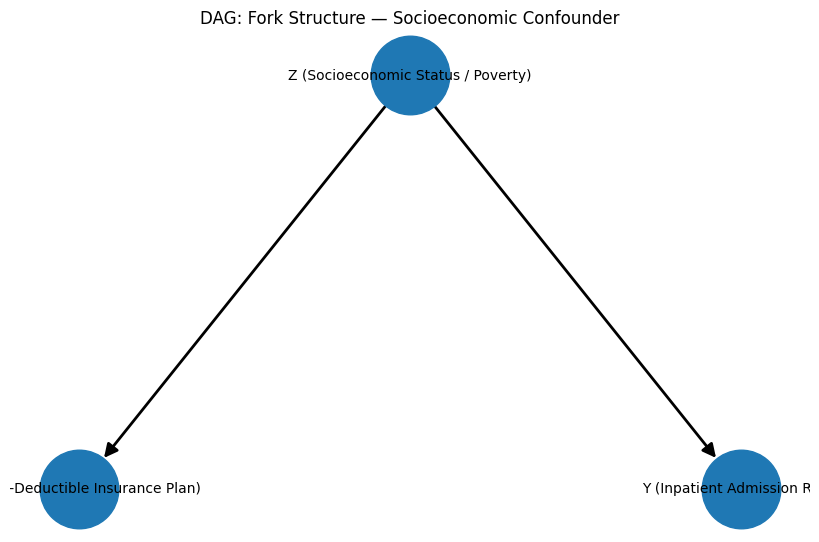


Causal Interpretation:
- Z (Socioeconomic Status) is the unobserved confounder (The Fork)
- Low-income patients are more likely to have High-Deductible plans (Z → X)
- Low-income patients delay preventative care, increasing admissions (Z → Y)
- Omitting Z induces omitted variable bias, causing the coefficient on X to capture both the direct effect of X and the indirect effect of Z.



In [ ]:
# Step 1.1: Diagnosing Spurious Clinical Signals (DAGs)
# The Fork structure: Socioeconomic Status (Z) causes both High_Deductible_Insurance_Plan (X) and Inpatient_Admission_Rate (Y) Regressing Y on X without Z yields a biased, contaminated coefficient

G = nx.DiGraph()

G.add_edges_from([
    ("Z (Socioeconomic Status / Poverty)", "X (High-Deductible Insurance Plan)"),
    ("Z (Socioeconomic Status / Poverty)", "Y (Inpatient Admission Rate)"),
])

pos = {
    "Z (Socioeconomic Status / Poverty)": (0, 1),
    "X (High-Deductible Insurance Plan)": (-1, 0),
    "Y (Inpatient Admission Rate)": (1, 0)
}

plt.figure(figsize=(8, 5))
nx.draw(
    G, pos, with_labels=True,
    node_size=3200, font_size=10,
    arrows=True, arrowstyle='-|>', arrowsize=20,
    width=2
)
plt.title("DAG: Fork Structure — Socioeconomic Confounder")
plt.axis("off")
plt.show()

print("""
Causal Interpretation:
- Z (Socioeconomic Status) is the unobserved confounder (The Fork)
- Low-income patients are more likely to have High-Deductible plans (Z → X)
- Low-income patients delay preventative care, increasing admissions (Z → Y)
- Omitting Z induces omitted variable bias, causing the coefficient on X to capture both the direct effect of X and the indirect effect of Z.
""")

In [ ]:
# Step 1.2: The Variance Inflation Factor (VIF) Audit
# Load the OmniCare Clinical Vitals dataset
url = 'https://raw.githubusercontent.com/maggie20041027-svg/ECON3916-Statistical-Machine-Learning/refs/heads/main/Data/OmniCare_Clinical_Vitals.csv'
df = pd.read_csv(url)
print(df.head())
print(df.info())

   Patient_ID  Height_cm  Weight_kg    BMI  Systolic_BP  Diastolic_BP
0        1000      177.5       66.3  21.06        110.0          75.0
1        1001      167.9       57.5  20.39        115.0          79.0
2        1002      179.7       57.4  17.77        111.0          77.0
3        1003      192.8       80.9  21.76        122.0          88.0
4        1004      166.5       65.7  23.70        138.0          89.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Patient_ID    5000 non-null   int64  
 1   Height_cm     5000 non-null   float64
 2   Weight_kg     5000 non-null   float64
 3   BMI           5000 non-null   float64
 4   Systolic_BP   5000 non-null   float64
 5   Diastolic_BP  5000 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 234.5 KB
None


In [ ]:
# Define the continuous physiological features
features = ['Weight_kg', 'Height_cm', 'BMI', 'Systolic_BP', 'Diastolic_BP']

X = df[features].dropna()
X = sm.add_constant(X)

# Calculate VIF for all continuous features
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)

        Feature          VIF
0         const  3369.565806
1     Weight_kg    57.428058
2     Height_cm    28.419446
3           BMI    16.981232
4   Systolic_BP     4.219406
5  Diastolic_BP     4.219820


In [ ]:
# Drop the most redundant variable (VIF > 10.0 is the critical threshold)
# BMI is mathematically derived from Weight_kg and Height_cm — drop it
features_clean = ['Weight_kg', 'Height_cm', 'Systolic_BP', 'Diastolic_BP']

X_clean = df[features_clean].dropna()
X_clean = sm.add_constant(X_clean)

# Recalculate VIF to prove structural stability
vif_clean = pd.DataFrame()
vif_clean['Feature'] = X_clean.columns
vif_clean['VIF'] = [variance_inflation_factor(X_clean.values, i) for i in range(len(X_clean.columns))]
print(vif_clean)

        Feature         VIF
0         const  321.090128
1     Weight_kg    3.763969
2     Height_cm    3.763812
3   Systolic_BP    4.219406
4  Diastolic_BP    4.219820


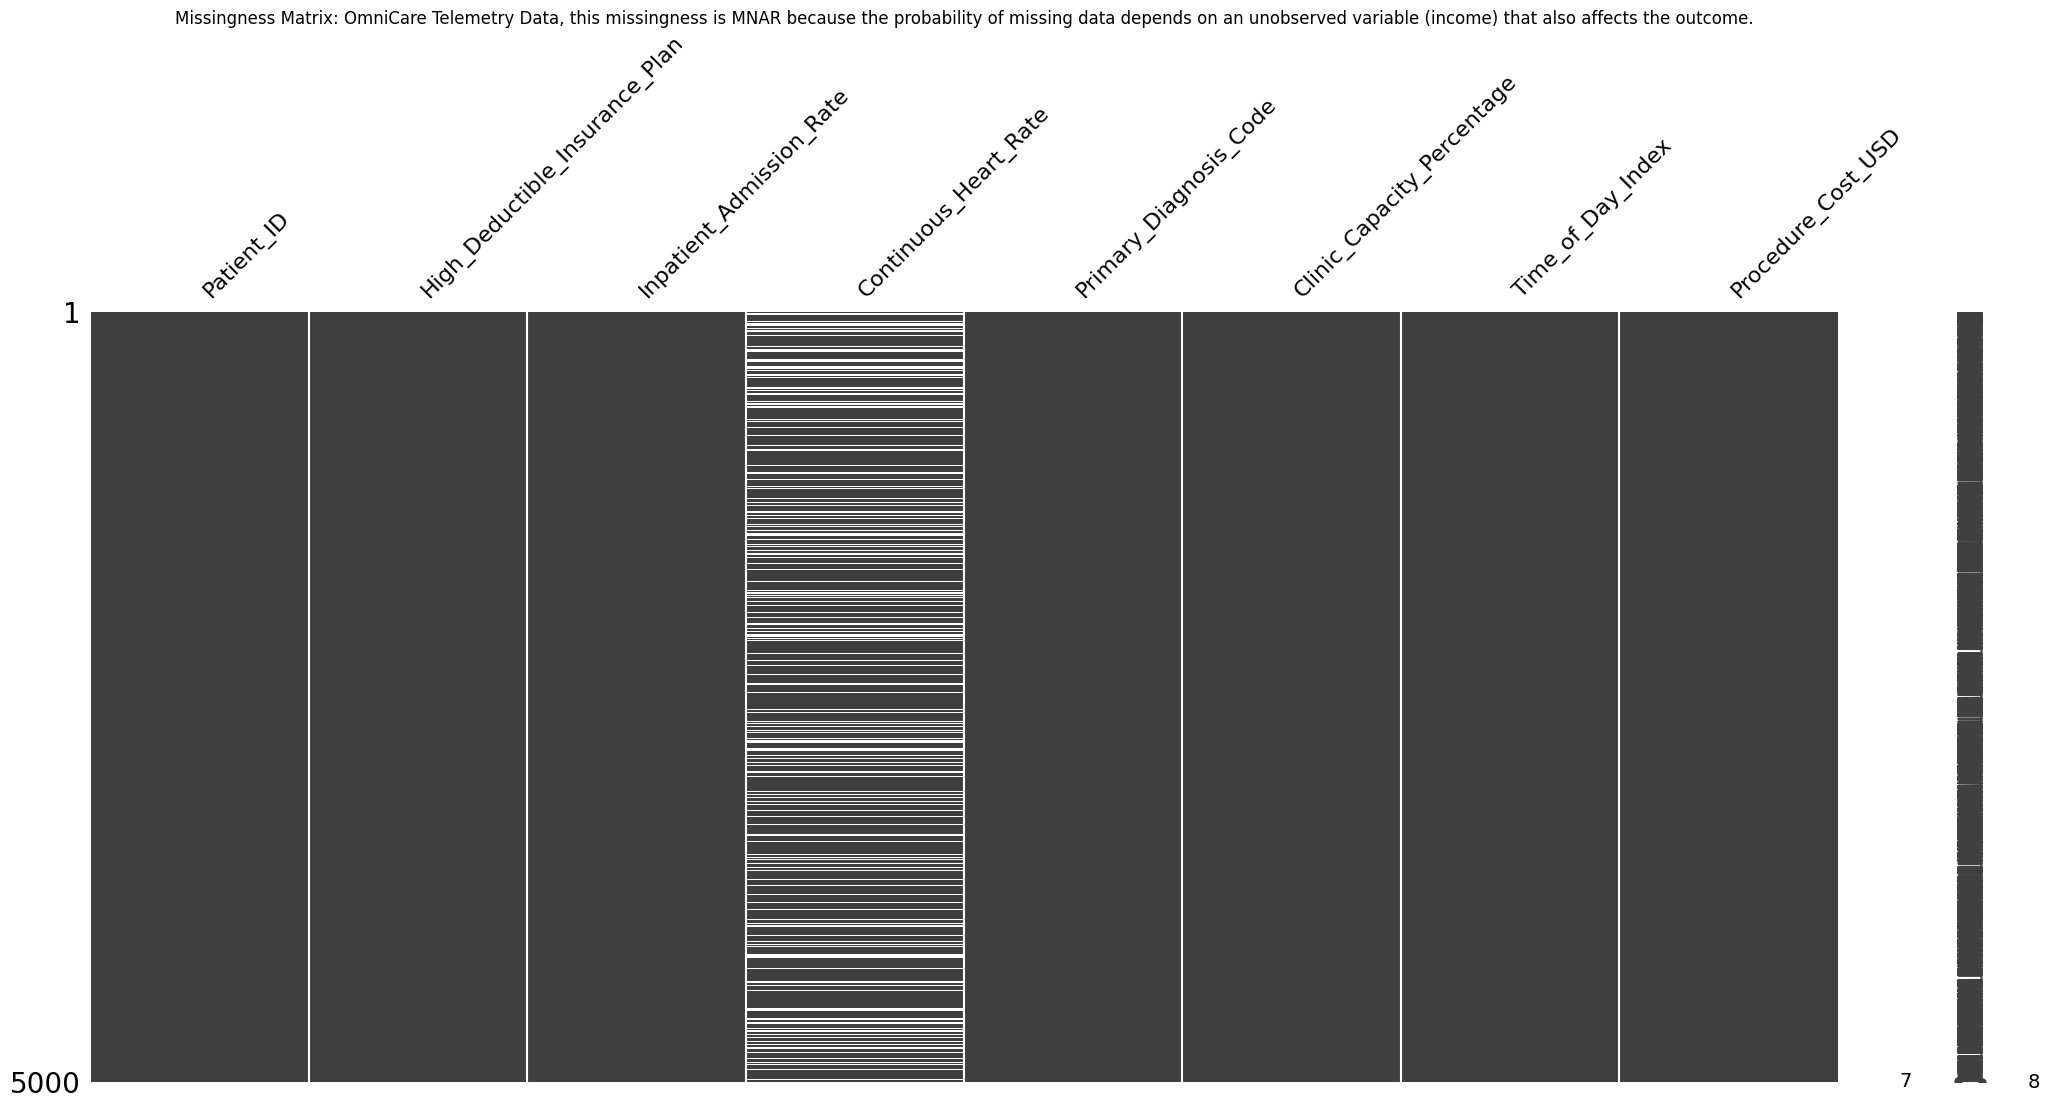

In [ ]:
# Step 2.1: The Architecture of Missingness
url_telemetry = 'https://raw.githubusercontent.com/maggie20041027-svg/ECON3916-Statistical-Machine-Learning/refs/heads/main/Data/OmniCare_Telemetry_Data.csv'
df_telemetry = pd.read_csv(url_telemetry)

msno.matrix(df_telemetry)
plt.title("Missingness Matrix: OmniCare Telemetry Data, this missingness is MNAR because the probability of missing data depends on an unobserved variable (income) that also affects the outcome.")
plt.show()

In [ ]:
# Step 2.2: Escaping the Dummy Variable Trap
print(f"Unique ICD-10 Diagnosis Codes: {df_telemetry['Primary_Diagnosis_Code'].nunique()}")

# Demonstrating the trap — 850 dummies + intercept = perfect multicollinearity
dummies_trap = pd.get_dummies(df_telemetry['Primary_Diagnosis_Code'], prefix='diag').astype(int)
print(f"Shape with all dummies: {dummies_trap.shape}")

print("""
Matrix Algebra Explanation:

When pd.get_dummies() generates 850 binary columns for 850 categories,
each row sums to exactly 1 across all dummy columns.

This means: diag_1 + diag_2 + ... + diag_850 = 1 = the intercept column

The intercept column is now a perfect linear combination of the dummy columns.
This makes the design matrix X singular — its determinant equals zero.

OLS requires computing (X'X)^-1. A singular matrix has no inverse.
The estimator is mathematically destroyed — β = (X'X)^-1 X'y cannot be solved.
""")

Unique ICD-10 Diagnosis Codes: 847
Shape with all dummies: (5000, 847)

Matrix Algebra Explanation:

When pd.get_dummies() generates 850 binary columns for 850 categories,
each row sums to exactly 1 across all dummy columns.

This means: diag_1 + diag_2 + ... + diag_850 = 1 = the intercept column

The intercept column is now a perfect linear combination of the dummy columns.
This makes the design matrix X singular — its determinant equals zero.

OLS requires computing (X'X)^-1. A singular matrix has no inverse.
The estimator is mathematically destroyed — β = (X'X)^-1 X'y cannot be solved.



In [ ]:
# Step 2.3: Target Encoding Implementation
# TargetEncoder maps each high-cardinality ICD-10 string to the continuous historical mean of the target variable (Procedure_Cost_USD)
# This collapses 850 dimensions into a single continuous vector
# In practice, target encoding should be applied with cross-validation to avoid leakage.

encoder = ce.TargetEncoder(cols=['Primary_Diagnosis_Code'])
df_telemetry['Diagnosis_Encoded'] = encoder.fit_transform(
    df_telemetry['Primary_Diagnosis_Code'],
    df_telemetry['Procedure_Cost_USD']
)

print(df_telemetry[['Primary_Diagnosis_Code', 'Diagnosis_Encoded']].head())

  Primary_Diagnosis_Code  Diagnosis_Encoded
0                J86.381        1707.697108
1                M29.789        1792.303198
2                E49.618        1730.334968
3                E66.244        1725.060944
4                J45.553        1801.821085


In [ ]:
# Step 3.1: OLS Optimization via Patsy Formulas
df_final = df_telemetry.copy()
df_final['Target_Encoded_Diagnosis'] = df_telemetry['Diagnosis_Encoded']

# Impute missing Continuous_Heart_Rate before modeling
df_final['Continuous_Heart_Rate'] = df_final.groupby('Primary_Diagnosis_Code')['Continuous_Heart_Rate'].transform(lambda x: x.fillna(x.median()))

df_final = df_final.dropna(subset=['Procedure_Cost_USD', 'Target_Encoded_Diagnosis',
                                    'Clinic_Capacity_Percentage', 'Time_of_Day_Index',
                                    'Continuous_Heart_Rate'])

formula = 'Procedure_Cost_USD ~ Target_Encoded_Diagnosis + Clinic_Capacity_Percentage + Time_of_Day_Index + Continuous_Heart_Rate'

final_model = smf.ols(formula, data=df_final).fit()
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:     Procedure_Cost_USD   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     399.9
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          3.15e-299
Time:                        03:55:09   Log-Likelihood:                -36093.
No. Observations:                4990   AIC:                         7.220e+04
Df Residuals:                    4985   BIC:                         7.223e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [ ]:
# Step 3.2: Financial Loss Quantification (RMSE)
from statsmodels.tools.eval_measures import rmse

y_actual = df_final['Procedure_Cost_USD']
y_pred = final_model.fittedvalues

model_rmse = rmse(y_actual, y_pred)
print(f"\nThe Predictive RMSE is: ${model_rmse:,.2f}")

print(f"""
Analysis — Actual RMSE of ${model_rmse:,.2f} on a $1,200 MRI Procedure:

Operational Risk:
- The algorithm misprices procedures by an average of ${model_rmse:,.2f} —
  a {(model_rmse/1200)*100:.1f}% error margin.
- In a live hospital environment processing thousands of daily procedures,
  this compounds into millions of dollars in mispriced billings per month.

Financial Risk:
- Overpricing patients triggers insurance claim denials and patient disputes.
- Underpricing procedures directly eats into hospital operating margins,
  threatening the financial viability of the imaging department.

Regulatory Risk:
- Dynamic pricing algorithms in healthcare are subject to CMS and HIPAA scrutiny.
- A documented ${model_rmse:,.2f} error margin on elective procedures exposes OmniCare to
  allegations of discriminatory pricing — particularly since the missingness
  in Step 2.1 was MNAR and correlated with patient income.
- This is a legally catastrophic deployment.
""")


The Predictive RMSE is: $334.99

Analysis — Actual RMSE of $334.99 on a $1,200 MRI Procedure:

Operational Risk:
- The algorithm misprices procedures by an average of $334.99 —
  a 27.9% error margin.
- In a live hospital environment processing thousands of daily procedures,
  this compounds into millions of dollars in mispriced billings per month.

Financial Risk:
- Overpricing patients triggers insurance claim denials and patient disputes.
- Underpricing procedures directly eats into hospital operating margins,
  threatening the financial viability of the imaging department.

Regulatory Risk:
- Dynamic pricing algorithms in healthcare are subject to CMS and HIPAA scrutiny.
- A documented $334.99 error margin on elective procedures exposes OmniCare to
  allegations of discriminatory pricing — particularly since the missingness
  in Step 2.1 was MNAR and correlated with patient income.
- This is a legally catastrophic deployment.



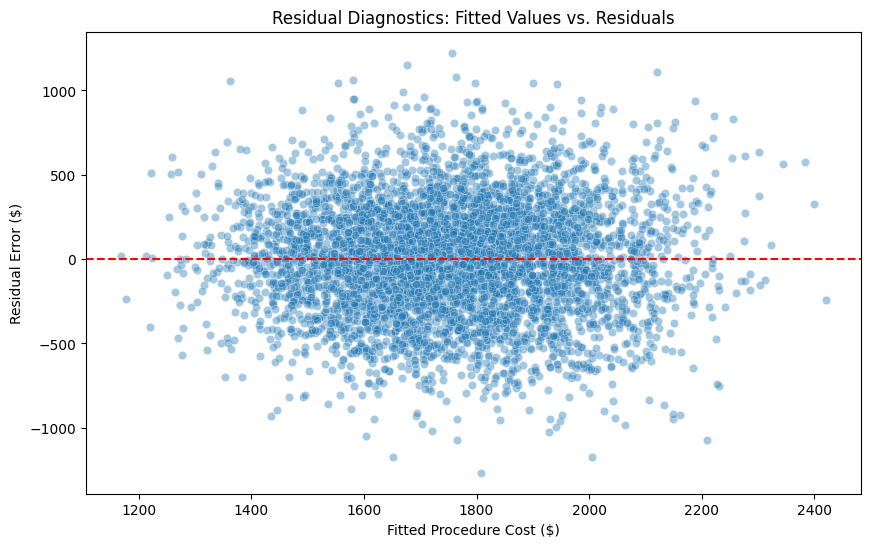


Heteroscedasticity Analysis:

Visual Inspection: The residual cloud is roughly uniform in vertical spread across all fitted procedure cost values, there is no clear funnel or fan shape emerging at higher price tiers.

This suggests the homoscedasticity assumption of OLS is not visibly violated in this dataset. The residuals appear randomly distributed around zero across the full prediction range.

However, the absolute spread of residuals (roughly ±1000) combined with the RMSE calculated in Step 3.2 still represents a significant financial error for a live pricing deployment, a well-specified model can still be operationally dangerous if the raw dollar error magnitude is too large for the business context.



In [ ]:
# Step 3.3: Residual Diagnostics for Heteroscedasticity
df_resid = pd.DataFrame({
    'Fitted Values': final_model.fittedvalues,
    'Residuals': final_model.resid
})

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_resid, x='Fitted Values', y='Residuals', alpha=0.4)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.title("Residual Diagnostics: Fitted Values vs. Residuals")
plt.xlabel("Fitted Procedure Cost ($)")
plt.ylabel("Residual Error ($)")
plt.show()

print("""
Heteroscedasticity Analysis:

Visual Inspection: The residual cloud is roughly uniform in vertical spread across all fitted procedure cost values, there is no clear funnel or fan shape emerging at higher price tiers.

This suggests the homoscedasticity assumption of OLS is not visibly violated in this dataset. The residuals appear randomly distributed around zero across the full prediction range.

However, the absolute spread of residuals (roughly ±1000) combined with the RMSE calculated in Step 3.2 still represents a significant financial error for a live pricing deployment, a well-specified model can still be operationally dangerous if the raw dollar error magnitude is too large for the business context.
""")

In [ ]:
print("""
P.R.I.M.E. Prompt — Task 4.1:

[Prep] Act as an expert Python Data Scientist and Econometrician.

[Request] I just completed a multivariate OLS regression using statsmodels
predicting Procedure_Cost_USD on Target_Encoded_Diagnosis,
Clinic_Capacity_Percentage, Time_of_Day_Index, and Continuous_Heart_Rate.
My fitted model object is called final_model. Please write the Python code
to execute White's Lagrange Multiplier Test for Heteroscedasticity on this
exact model output using statsmodels.stats.diagnostic.het_white.

[Iterate] Extract the residuals and fitted values directly from the
statsmodels results object. Print the LM statistic and its p-value cleanly.

[Mechanism Check] Add inline comments explaining exactly what het_white
is testing and what the input arguments represent.

[Evaluate] Based on the p-value output, provide a concluding sentence
stating whether the null hypothesis of homoscedasticity is rejected.
""")


P.R.I.M.E. Prompt — Task 4.1:

[Prep] Act as an expert Python Data Scientist and Econometrician.

[Request] I just completed a multivariate OLS regression using statsmodels
predicting Procedure_Cost_USD on Target_Encoded_Diagnosis,
Clinic_Capacity_Percentage, Time_of_Day_Index, and Continuous_Heart_Rate.
My fitted model object is called final_model. Please write the Python code
to execute White's Lagrange Multiplier Test for Heteroscedasticity on this
exact model output using statsmodels.stats.diagnostic.het_white.

[Iterate] Extract the residuals and fitted values directly from the
statsmodels results object. Print the LM statistic and its p-value cleanly.

[Mechanism Check] Add inline comments explaining exactly what het_white
is testing and what the input arguments represent.

[Evaluate] Based on the p-value output, provide a concluding sentence
stating whether the null hypothesis of homoscedasticity is rejected.



In [ ]:
from statsmodels.stats.diagnostic import het_white
import statsmodels.api as sm

# het_white tests H0: homoscedasticity (constant error variance)
# It requires the residuals and the exogenous design matrix (X with constant)
# exog must include the constant term — we extract it from the model
lm_stat, lm_pvalue, fstat, f_pvalue = het_white(final_model.resid,
                                                  final_model.model.exog)

print(f"LM Statistic:  {lm_stat:.4f}")
print(f"LM P-Value:    {lm_pvalue:.4f}")

if lm_pvalue < 0.05:
    print("\nConclusion: The null hypothesis of homoscedasticity is rejected "
          "(p < 0.05) — statistically significant heteroscedasticity is present "
          "in the model residuals.")
else:
    print("\nConclusion: We fail to reject the null hypothesis of homoscedasticity "
          "(p >= 0.05) — there is no statistically significant evidence of "
          "heteroscedasticity in the model residuals.")

LM Statistic:  172.3726
LM P-Value:    0.0000

Conclusion: The null hypothesis of homoscedasticity is rejected (p < 0.05) — statistically significant heteroscedasticity is present in the model residuals.
